# 02 — Feature Engineering


### Load data


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)
DATA_DIR = Path('../../data/processed')

df = pd.read_parquet(DATA_DIR / 'ml_prepared.parquet')

print(f'Shape: {df.shape}')
print(df.dtypes)

Shape: (5815, 14)
price                     float64
room_type                  object
property_type              object
accommodates                int64
bedrooms                  float64
bathrooms                  object
beds                      float64
availability_365            int64
minimum_nights              int64
number_of_reviews           int64
review_scores_rating      float64
host_is_superhost          object
instant_bookable           object
neighbourhood_cleansed     object
dtype: object


### Extract bathrooms number from text

In [55]:
df['bathrooms'].head(10)
print(df['bathrooms'].value_counts())
print(df['bathrooms'].isna().sum())

bathrooms
1.0     3895
1.5     1280
2.0      337
2.5      111
3.0       66
0.0       57
0.5       29
3.5       20
4.0        5
5.5        5
5.0        4
4.5        3
12.0       1
17.0       1
6.0        1
Name: count, dtype: int64
0


In [56]:

print(f"Original data type : {df['bathrooms'].dtype}")

df["bathrooms"] = pd.to_numeric(
    df["bathrooms"],
    errors="coerce"
)

median_bathrooms = df["bathrooms"].median()
df["bathrooms"] = df["bathrooms"].fillna(median_bathrooms)

# Check results
print(f"New data type      : {df['bathrooms'].dtype}")
print(f"Median used        : {median_bathrooms}")
print(f"Missing values     : {df['bathrooms'].isna().sum()}")

print("\nBathroom Distribution")
print(df["bathrooms"].value_counts().head(10))

Original data type : object
New data type      : float64
Median used        : 1.0
Missing values     : 0

Bathroom Distribution
bathrooms
1.0    3895
1.5    1280
2.0     337
2.5     111
3.0      66
0.0      57
0.5      29
3.5      20
4.0       5
5.5       5
Name: count, dtype: int64


In [57]:
df.columns

Index(['price', 'room_type', 'property_type', 'accommodates', 'bedrooms',
       'bathrooms', 'beds', 'availability_365', 'minimum_nights',
       'number_of_reviews', 'review_scores_rating', 'host_is_superhost',
       'instant_bookable', 'neighbourhood_cleansed'],
      dtype='object')

### Encode categorical columns

In [58]:

df["is_superhost"] = (
    df["host_is_superhost"]
      .map({"t": 1, "f": 0, True: 1, False: 0})
      .fillna(0)
      .astype(int)
)

# One-Hot Encode Room Type
room_dummies = pd.get_dummies(
    df["room_type"],
    prefix="room",
    drop_first=True,
    dtype=int
)

# One-Hot Encode Property Type
property_dummies = pd.get_dummies(
    df["property_type"],
    prefix="property",
    drop_first=True,
    dtype=int
)

# One-Hot Encode Neighbourhood
neighbourhood_dummies = pd.get_dummies(
    df["neighbourhood_cleansed"],
    prefix="neighbourhood",
    drop_first=True,
    dtype=int
)

# Combine encoded columns with the dataset
df = pd.concat(
    [
        df,
        room_dummies,
        property_dummies,
        neighbourhood_dummies
    ],
    axis=1
)

print("Categorical encoding completed.")
print(f"Dataset shape: {df.shape}")

Categorical encoding completed.
Dataset shape: (5815, 95)


### Create derived features

In [59]:
# Price per bedroom (useful ratio — controls for size)
df['price_per_bedroom'] = np.where(
    df['bedrooms'] > 0,
    df['price'] / df['bedrooms'],
    df['price']  # studio = full price
)

# Guest per bedroom ratio
df['guests_per_bedroom'] = np.where(
    df['bedrooms'] > 0,
    df['accommodates'] / df['bedrooms'],
    df['accommodates']
)

# Review density — reviews per available day
# High value = frequently booked relative to availability
df['review_density'] = np.where(
    df['availability_365'] > 0,
    df['number_of_reviews'] / df['availability_365'],
    0
).round(4)

# Has reviews flag
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

# Highly reviewed flag
df['is_popular'] = (df['number_of_reviews'] >= 20).astype(int)

print('Derived features created:')
for col in ['price_per_bedroom','guests_per_bedroom','review_density','has_reviews','is_popular']:
    print(f'  {col}: mean={df[col].mean():.3f}')

Derived features created:
  price_per_bedroom: mean=242.403
  guests_per_bedroom: mean=2.081
  review_density: mean=1.344
  has_reviews: mean=0.888
  is_popular: mean=0.387


## Step 4 — Log-transform price

Why: price is right-skewed (most listings €60-300, a few at €80,000).
Log transform makes the distribution more symmetric so the model
treats all price ranges equally during training.

We ALWAYS reverse this (np.expm1) before reporting errors in euros.

In [60]:
df['price'].describe()

count     5815.000000
mean       336.707137
std       1995.308484
min         35.000000
25%        161.000000
50%        222.000000
75%        313.500000
max      80018.000000
Name: price, dtype: float64

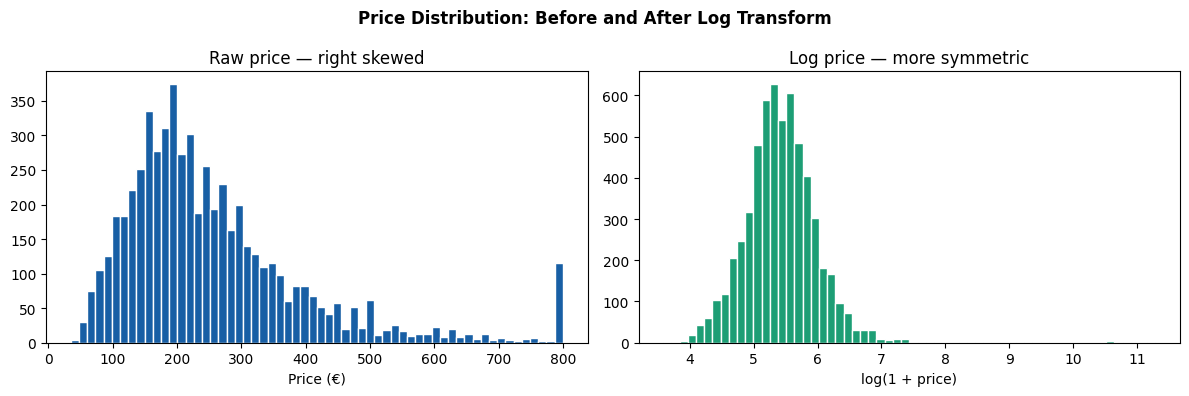

Raw price  — skewness: 31.41
Log price  — skewness: 1.48
(Closer to 0 = more symmetric = better for linear models)


In [61]:
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Price Distribution: Before and After Log Transform', fontweight='bold')

axes[0].hist(df['price'].clip(upper=800), bins=60,
             color='#185FA5', edgecolor='white')
axes[0].set_title('Raw price — right skewed')
axes[0].set_xlabel('Price (€)')

axes[1].hist(df['log_price'], bins=60,
             color='#1D9E75', edgecolor='white')
axes[1].set_title('Log price — more symmetric')
axes[1].set_xlabel('log(1 + price)')

plt.tight_layout()
plt.savefig('../../reports/fig_ml_log_transform.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Raw price  — skewness: {df["price"].skew():.2f}')
print(f'Log price  — skewness: {df["log_price"].skew():.2f}')
print('(Closer to 0 = more symmetric = better for linear models)')

In [62]:
df.columns

Index(['price', 'room_type', 'property_type', 'accommodates', 'bedrooms',
       'bathrooms', 'beds', 'availability_365', 'minimum_nights',
       'number_of_reviews',
       ...
       'neighbourhood_Slotervaart', 'neighbourhood_Watergraafsmeer',
       'neighbourhood_Westerpark', 'neighbourhood_Zuid', 'price_per_bedroom',
       'guests_per_bedroom', 'review_density', 'has_reviews', 'is_popular',
       'log_price'],
      dtype='object', length=101)

In [63]:
df.shape

(5815, 101)

In [73]:
import json
from pathlib import Path
import pandas as pd
NUMERIC_FEATURES = [
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'availability_365', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating',
    'neighbourhood_price_encoded',
    'price_per_bedroom', 'guests_per_bedroom',
    'review_density', 'is_superhost',
    'has_reviews', 'is_popular',
]

ROOM_FEATURES = [c for c in df.columns if c.startswith('room_')]
PROP_FEATURES = [c for c in df.columns if c.startswith('prop_')]

ALL_FEATURES = NUMERIC_FEATURES + ROOM_FEATURES + PROP_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

TARGET = 'log_price'

# 2. RESOLVE DUPLICATES & BUILD MODEL DATAFRAME

extra_cols = [TARGET, 'price', 'room_type', 'neighbourhood_cleansed']
final_columns = ALL_FEATURES + [col for col in extra_cols if col not in ALL_FEATURES]

model_df = df[final_columns].copy()
model_df = model_df.dropna()

# 3. REPORTING LAYER

print(f'Final dataset shape: {model_df.shape}')
print(f'Features listed     : {len(ALL_FEATURES)}')
print(f'\nAll features:')
for i, f in enumerate(ALL_FEATURES, 1):
    print(f'  {i:2d}. {f}')

# 4. EXPORT ARTIFACTS TO ROOT DATA/PROCESSED (Fixed Paths)

output_dir = Path('../../Data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Save processed dataframe safely to Parquet format
parquet_path = output_dir / 'model_ready.parquet'
model_df.to_parquet(parquet_path, index=False)
print(f'\n Saved dataset safely to: {parquet_path}')

# Save the feature configuration keys to JSON inside the same processed folder
json_path = output_dir / 'feature_list.json'
with open(json_path, 'w') as f:
    json.dump(ALL_FEATURES, f)
print(f' Saved feature list tracking configuration to: {json_path}')

Final dataset shape: (5815, 21)
Features listed     : 18

All features:
   1. accommodates
   2. bedrooms
   3. bathrooms
   4. beds
   5. availability_365
   6. minimum_nights
   7. number_of_reviews
   8. review_scores_rating
   9. price_per_bedroom
  10. guests_per_bedroom
  11. review_density
  12. is_superhost
  13. has_reviews
  14. is_popular
  15. room_type
  16. room_Hotel room
  17. room_Private room
  18. room_Shared room

 Saved dataset safely to: ..\..\Data\processed\model_ready.parquet
 Saved feature list tracking configuration to: ..\..\Data\processed\feature_list.json
